# Teaching a Computer to Read a Chessboard
### The full story of the OpenCV Chess Bot's piece recognition — data, labels, training, and the bugs along the way

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/7dpk/OpenCV-Chess-Bot/blob/main/docs/piece_recognition_walkthrough.ipynb)

I wanted my chess bot to look at a screen — any screen — and know exactly which piece
stands on each of the 64 squares. No site APIs, no browser plugins: just pixels in,
chess position out. This notebook retells how that was built, step by step, with
runnable code and a picture at every stage:

1. **Collecting the data** — where 100 % of the training images come from
2. **Labelling** — how I got half a million labels without labelling anything by hand
3. **Train/validation split** — making the numbers honest
4. **The model** — a CNN small enough to live in a git repo
5. **Training** — including a quick one you can run right here
6. **Validation & evaluation** — the three gates a model must pass
7. **Reading a full board** — end-to-end demo
8. **The confidence bug hunt** — when it all worked in tests and failed on real screens

Everything runs top-to-bottom in Google Colab (or locally from the repo). The heavy
lifting was done once on my machine; here we download ~4 MB of piece art, build a
small demo dataset, and use the trained model that ships with the repo.

In [1]:
# Setup — works in Google Colab and locally inside the repo
import os, sys, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip -q install python-chess cairosvg
    !apt-get -qq -y install libcairo2 > /dev/null 2>&1
    import pathlib
    if not pathlib.Path("OpenCV-Chess-Bot").exists():
        !git clone -q https://github.com/7dpk/OpenCV-Chess-Bot.git
    %cd -q OpenCV-Chess-Bot

if sys.platform == "darwin":  # macOS: cairosvg needs homebrew's cairo on the dyld path
    os.environ.setdefault("DYLD_FALLBACK_LIBRARY_PATH", "/opt/homebrew/lib")

REPO = Path.cwd()
while not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
os.chdir(REPO)

import chess
import cv2
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image

from chessbot.vision.position import CLASSES, board_to_grid
from chessbot.vision.recognizer import INPUT_SIZE, Recognizer

# a small consistent chart style (validated, colorblind-safe palette)
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE, BASELINE = "#e1e0d9", "#fcfcfb", "#c3c2b7"
BLUE, AQUA, YELLOW, RED = "#2a78d6", "#1baf7a", "#eda100", "#e34948"
BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.axisbelow": True, "figure.dpi": 110, "font.size": 9,
})

def show_bgr(ax, img_bgr, title=None):
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=8, color=INK2)

MODEL_PATH = REPO / "models/piece_classifier.onnx"
recognizer = Recognizer(model_path=MODEL_PATH)
print(f"ready — model: {MODEL_PATH.name} ({MODEL_PATH.stat().st_size // 1024} KB), "
      f"{len(CLASSES)} classes: {CLASSES}")

ready — model: piece_classifier.onnx (373 KB), 13 classes: ['empty', 'wP', 'wN', 'wB', 'wR', 'wQ', 'wK', 'bP', 'bN', 'bB', 'bR', 'bQ', 'bK']


## The goal

The bot's pipeline is a chain of five stages. This notebook is about the highlighted
one — everything else (finding the board, diffing frames, moving the mouse) only
works if the recognizer is right, because **one misread square makes an illegal
chess position**.

The recognizer must be:

- **theme-proof** — players pick from dozens of piece styles and board colours;
- **fast on CPU** — it runs inside a game loop, no GPU assumed;
- **honest about uncertainty** — the bot should *know* when it isn't sure, instead
  of silently playing from a wrong position.

Each square becomes one of **13 classes**: `empty`, or {white, black} × {pawn,
knight, bishop, rook, queen, king}.

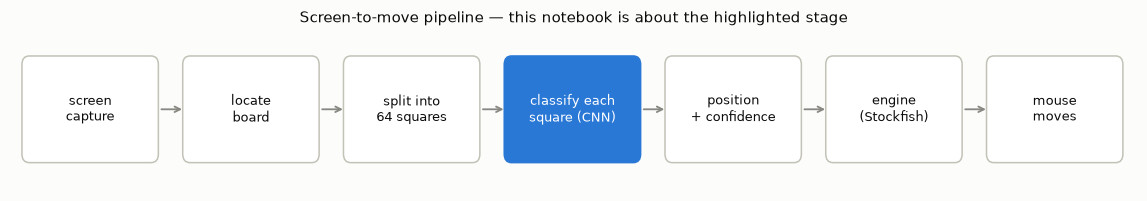

In [2]:
# The pipeline at a glance
fig, ax = plt.subplots(figsize=(10.5, 1.9))
ax.set_axis_off(); ax.grid(False)
stages = ["screen\ncapture", "locate\nboard", "split into\n64 squares",
          "classify each\nsquare (CNN)", "position\n+ confidence",
          "engine\n(Stockfish)", "mouse\nmoves"]
for i, label in enumerate(stages):
    x = i * 1.32
    hot = i == 3
    box = mpl.patches.FancyBboxPatch((x, 0.25), 1.0, 0.62, boxstyle="round,pad=0.06",
        fc=BLUE if hot else "white", ec=BLUE if hot else BASELINE, lw=1.0)
    ax.add_patch(box)
    ax.text(x + 0.5, 0.56, label, ha="center", va="center", fontsize=8.5,
            color="white" if hot else INK, zorder=3)
    if i < len(stages) - 1:
        ax.annotate("", xy=(x + 1.28, 0.56), xytext=(x + 1.06, 0.56),
                    arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
ax.set_xlim(-0.15, len(stages) * 1.32 - 0.15); ax.set_ylim(0, 1.1)
ax.set_title("Screen-to-move pipeline — this notebook is about the highlighted stage",
             fontsize=10, color=INK, pad=6)
plt.tight_layout(); plt.show()

## 1. Collecting the data

My first instinct was the obvious one: take lots of screenshots and label them.
A quick estimate killed that idea — a robust classifier wants tens of thousands of
examples per class, across every piece style × board theme × size combination.
That is months of clicking.

Then the realisation: **chess sites render the board from art they publish.**
Lichess keeps every piece set as an SVG in its open-source repo; chess.com serves
its sets as PNGs from a public CDN; lichess also publishes its board textures
(wood, marble, metal…). If I collect the *ingredients*, I can cook unlimited
labelled screenshots myself.

`training/fetch_assets.py` downloads the whole pantry — ~4 MB:

```python
LICHESS = "https://raw.githubusercontent.com/lichess-org/lila/master/public"
piece_url = f"{LICHESS}/piece/cburnett/wN.svg"          # every set, every piece
board_url = f"{LICHESS}/images/board/wood.jpg"           # board textures
chesscom  = "https://images.chesscomfiles.com/chess-themes/pieces/neo/150/wn.png"
```

The cell below fetches everything (skips files already on disk) and shows what one
piece looks like across styles — this variety is exactly why a lookup table won't
work and a small neural network will.

41 complete piece sets, 17 board textures


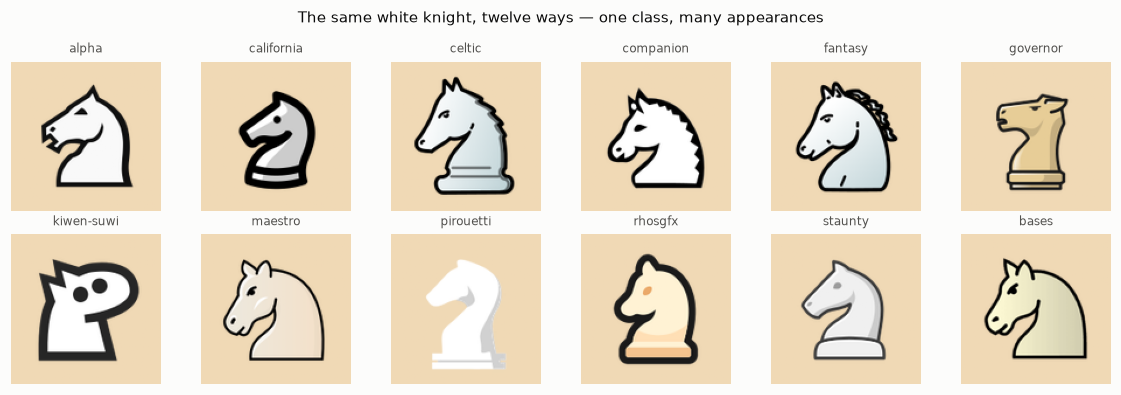

In [3]:
from training.fetch_assets import PIECE_CODES, fetch_all
from training.generate_dataset import VAL_SETS, load_piece_set

ASSETS = REPO / "training/assets"
if not list(ASSETS.glob("lichess/*/wN.svg")):
    print("downloading piece art (~4 MB)...")
    print(fetch_all(ASSETS))

inventory = {}
for source in ("lichess", "chesscom"):
    for set_dir in sorted((ASSETS / source).iterdir()):
        if set_dir.is_dir() and len(list(set_dir.glob("*.svg")) + list(set_dir.glob("*.png"))) == 12:
            inventory[set_dir.name] = set_dir
n_boards = len(list((ASSETS / "boards").iterdir()))
print(f"{len(inventory)} complete piece sets, {n_boards} board textures")

sample_sets = [s for s in list(inventory)[::max(1, len(inventory) // 12)]][:12]
fig, axes = plt.subplots(2, 6, figsize=(10.5, 3.6))
fig.suptitle("The same white knight, twelve ways — one class, many appearances",
             fontsize=10, color=INK)
for ax, name in zip(axes.flat, sample_sets):
    pieces = load_piece_set(inventory[name])
    tile = Image.new("RGBA", (128, 128), (240, 217, 181, 255))
    tile.alpha_composite(pieces["wN"].resize((108, 108), Image.LANCZOS), (10, 10))
    ax.imshow(tile); ax.set_axis_off()
    ax.set_title(name, fontsize=8, color=INK2)
plt.tight_layout(); plt.show()

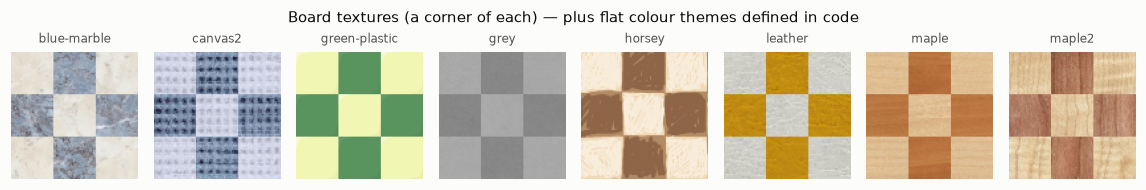

In [4]:
# and the boards those pieces stand on
boards = sorted((ASSETS / "boards").iterdir())[:8]
fig, axes = plt.subplots(1, 8, figsize=(10.5, 1.7))
fig.suptitle("Board textures (a corner of each) — plus flat colour themes defined in code",
             fontsize=10, color=INK)
for ax, path in zip(axes.flat, boards):
    img = cv2.imread(str(path))
    show_bgr(ax, cv2.resize(img, (256, 256))[:96, :96], path.stem)
plt.tight_layout(); plt.show()

## 2. Labelling — without labelling

Here is the trick that makes the whole project cheap: **if you place the piece
yourself, you already know the label.** Nobody ever drew a bounding box for this
dataset. A training image is *manufactured*:

1. pick a square background (flat theme colour or a crop of a board texture);
2. maybe tint it with a translucent highlight (sites mark the last move this way);
3. paste a piece PNG/SVG onto it — **the label is whatever piece we pasted**;
4. add the clutter a real screen adds: legal-move dots, capture rings, a mouse
   cursor, slivers of neighbouring pieces bleeding over the square edge;
5. rough it up: random size (28–128 px), brightness/contrast jitter, blur, JPEG
   compression — then resize to the model's 48×48 input.

Every random choice widens the training distribution. In its simplest form the
generator is just this:

```python
def make_example(piece_name, background, rng):
    square = background.copy()                       # 1. the empty square
    if piece_name != "empty":
        piece = load_piece_image(piece_name)         # 3. paste the piece...
        square.alpha_composite(piece, jitter(rng))
    square = add_screen_clutter(square, rng)         # 4. dots, cursor, bleed
    square = degrade(square, rng)                    # 5. size, blur, jpeg
    return square, piece_name                        # ...and the label is free!
```

The real implementation is `render_square()` in `training/generate_dataset.py`.

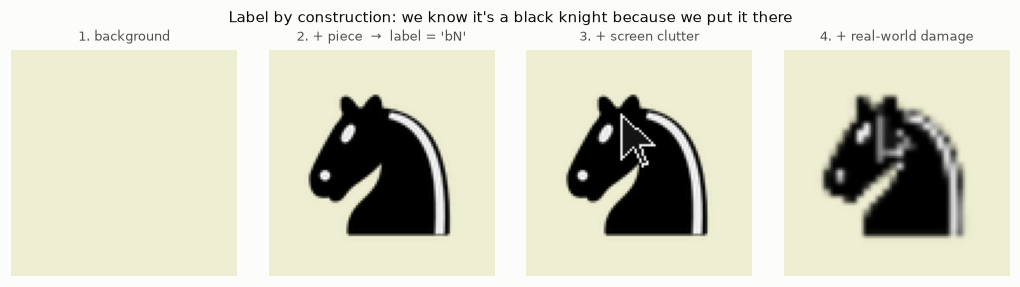

In [5]:
# The recipe, visualised: background + piece + clutter -> a labelled crop
from training.generate_dataset import FLAT_THEMES, _draw_cursor, _draw_move_marker
import random

rng = random.Random(4)
cburnett = load_piece_set(inventory["cburnett"])
bg = Image.new("RGBA", (96, 96), (238, 238, 210, 255))
piece = cburnett["bN"].resize((80, 80), Image.LANCZOS)
with_piece = bg.copy(); with_piece.alpha_composite(piece, (8, 8))
cluttered = with_piece.copy(); _draw_cursor(cluttered, random.Random(3))
degraded = cv2.cvtColor(np.asarray(cluttered.convert("RGB")), cv2.COLOR_RGB2BGR)
degraded = cv2.GaussianBlur(cv2.resize(cv2.resize(degraded, (34, 34)), (96, 96),
                            interpolation=cv2.INTER_AREA), (3, 3), 0)

fig, axes = plt.subplots(1, 4, figsize=(9.5, 2.6))
panels = [("1. background", np.asarray(bg.convert("RGB"))),
          ("2. + piece  →  label = 'bN'", np.asarray(with_piece.convert("RGB"))),
          ("3. + screen clutter", np.asarray(cluttered.convert("RGB"))),
          ("4. + real-world damage", cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB))]
for ax, (title, img) in zip(axes.flat, panels):
    ax.imshow(img); ax.set_axis_off(); ax.set_title(title, fontsize=8.5, color=INK2)
fig.suptitle("Label by construction: we know it's a black knight because we put it there",
             fontsize=10, color=INK)
plt.tight_layout(); plt.show()

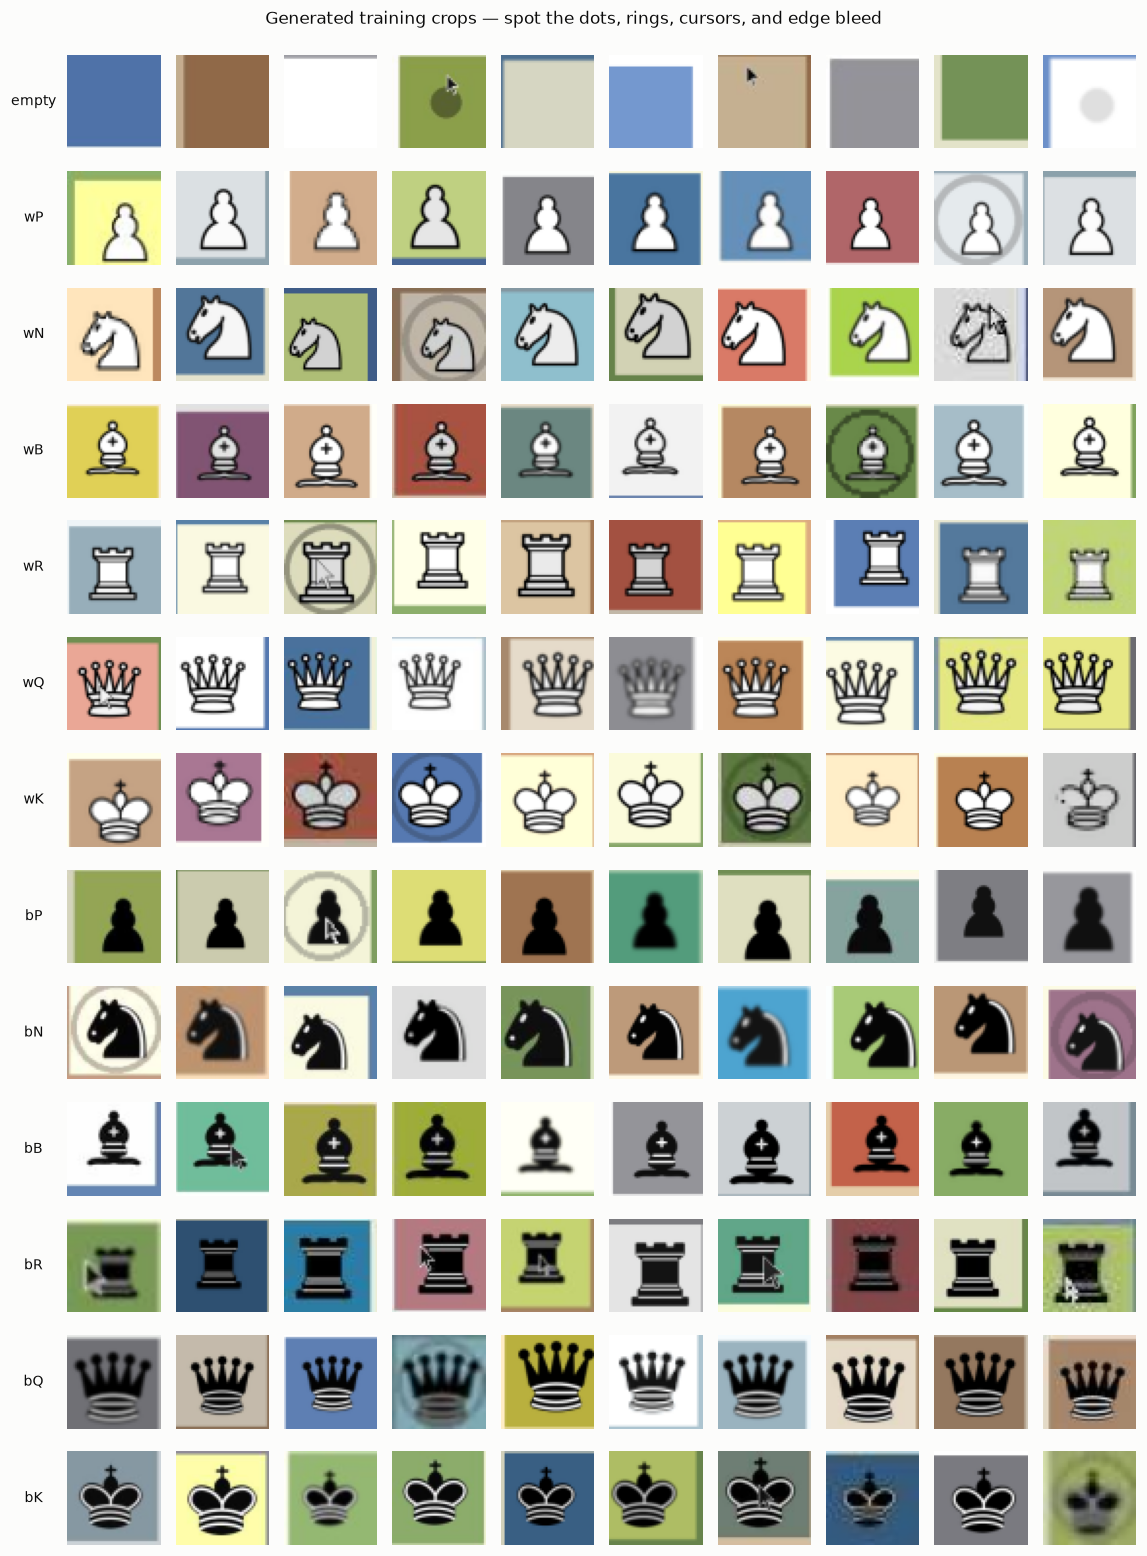

In [6]:
# The full generator in action: one row per class, ten random draws each
from training.generate_dataset import render_square

rng = random.Random(11)
neighbors = list(cburnett.values())
fig, axes = plt.subplots(13, 10, figsize=(10.5, 14.2))
fig.suptitle("Generated training crops — spot the dots, rings, cursors, and edge bleed",
             fontsize=11, color=INK, y=0.995)
for row, label in enumerate(CLASSES):
    piece_img = None if label == "empty" else cburnett[label]
    for col in range(10):
        light, dark = rng.choice(FLAT_THEMES)
        crop = render_square(piece_img, light, dark, rng.random() < 0.5, rng,
                             neighbors=neighbors)
        show_bgr(axes[row][col], crop)
    axes[row][0].set_ylabel(label, rotation=0, labelpad=22, fontsize=9,
                            color=INK, va="center")
    axes[row][0].set_axis_on(); axes[row][0].set_xticks([]); axes[row][0].set_yticks([])
    for spine in axes[row][0].spines.values():
        spine.set_visible(False)
plt.tight_layout(); plt.show()

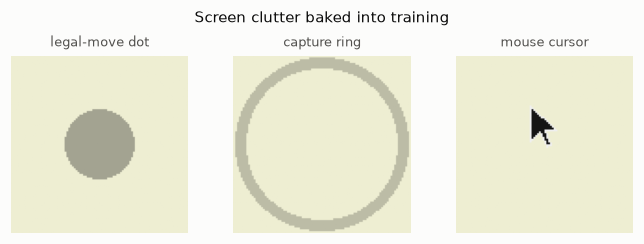

In [7]:
# The three artifacts that real chess sites draw on top of the board.
# We'll meet them again in the bug-hunt section — the original model had
# never seen them, and it showed.
demos = []
base_sq = Image.new("RGBA", (96, 96), (238, 238, 210, 255))
for title, fn in [
    ("legal-move dot", lambda c: _draw_move_marker(c, random.Random(1), occupied=False)),
    ("capture ring", lambda c: _draw_move_marker(c, random.Random(2), occupied=True)),
    ("mouse cursor", lambda c: _draw_cursor(c, random.Random(3))),
]:
    canvas = base_sq.copy(); fn(canvas); demos.append((title, canvas))
fig, axes = plt.subplots(1, 3, figsize=(6.2, 2.2))
fig.suptitle("Screen clutter baked into training", fontsize=10, color=INK)
for ax, (title, canvas) in zip(axes.flat, demos):
    ax.imshow(canvas); ax.set_axis_off(); ax.set_title(title, fontsize=8.5, color=INK2)
plt.tight_layout(); plt.show()

## 3. A train/validation split you can trust

A dataset made by a generator has a trap: if training *and* validation images come
from the same piece sets, validation only proves the model memorised those styles.
The accuracy number would be flattering and useless.

So the split is **by piece set, not by image**. Five sets — `staunty`, `governor`,
`icpieces`, `kosal`, `glass` — never appear in training at all. When validation
says 98 %, that is 98 % *on piece styles the model has never seen*, which is the
question that actually matters: will it generalise to a theme it wasn't built on?

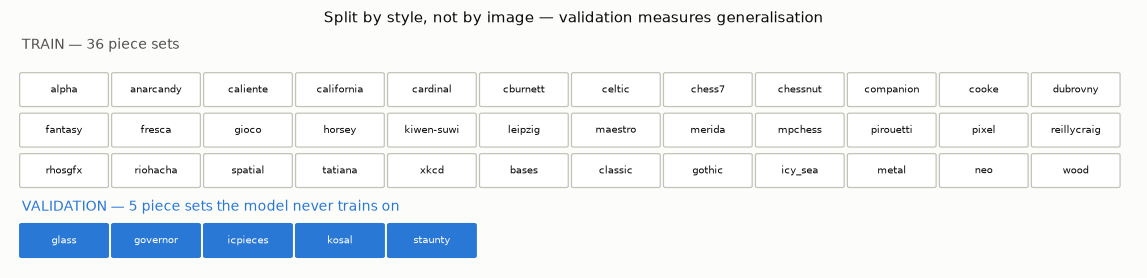

dataset on disk: 112,320 train / 5,200 val images (13 perfectly balanced classes)


In [8]:
# Split diagram + build the dataset (small demo size here; the shipped model
# used --per-class 240, ~115k images)
from training.generate_dataset import build_dataset

DATASET = REPO / "training/dataset"
if not (DATASET / "train").exists():
    print("generating a demo dataset (a few minutes)...")
    build_dataset(ASSETS, DATASET, per_class=40)

train_sets = [s for s in inventory if s not in VAL_SETS]
fig, ax = plt.subplots(figsize=(10.5, 2.6))
ax.set_axis_off(); ax.grid(False)
for i, name in enumerate(train_sets):
    r, c = divmod(i, 12)
    ax.add_patch(mpl.patches.FancyBboxPatch((c * 0.85, 1.9 - r * 0.55), 0.78, 0.42,
                 boxstyle="round,pad=0.02", fc="white", ec=BASELINE, lw=0.8))
    ax.text(c * 0.85 + 0.39, 2.11 - r * 0.55, name, ha="center", va="center", fontsize=6.5)
for i, name in enumerate(sorted(VAL_SETS)):
    ax.add_patch(mpl.patches.FancyBboxPatch((i * 0.85, -0.15), 0.78, 0.42,
                 boxstyle="round,pad=0.02", fc=BLUE, ec=BLUE, lw=0.8))
    ax.text(i * 0.85 + 0.39, 0.06, name, ha="center", va="center", fontsize=6.5, color="white")
ax.text(0, 2.62, f"TRAIN — {len(train_sets)} piece sets", fontsize=9, color=INK2, va="bottom")
ax.text(0, 0.42, "VALIDATION — 5 piece sets the model never trains on", fontsize=9,
        color=BLUE, va="bottom")
ax.set_xlim(-0.1, 10.3); ax.set_ylim(-0.3, 2.9)
ax.set_title("Split by style, not by image — validation measures generalisation",
             fontsize=10, color=INK)
plt.tight_layout(); plt.show()

counts = {split: sum(len(list((DATASET / split / c).glob("*.png"))) for c in CLASSES)
          for split in ("train", "val")}
print(f"dataset on disk: {counts['train']:,} train / {counts['val']:,} val images "
      f"({13} perfectly balanced classes)")

## 4. The model: PieceNet

Once the board is split into squares, classification is an easy vision problem —
the piece is centred, there's nothing to localise. So the network is deliberately
tiny: three conv blocks that halve the image while widening the channels, global
average pooling, and one linear layer. About **95 k parameters, ~370 KB as ONNX** —
small enough to commit to git and fast enough to classify all 64 squares in a few
milliseconds on a CPU.

Two design choices worth stealing:

- **Global average pooling** instead of `Flatten → Dense` removes ~90 % of the
  parameters a naive design would have *and* adds tolerance to the piece being a
  few pixels off-centre — which, as we'll see, real crops often are.
- **Export to ONNX, run with OpenCV.** The bot never imports PyTorch; training
  and playing have completely separate dependency stacks.

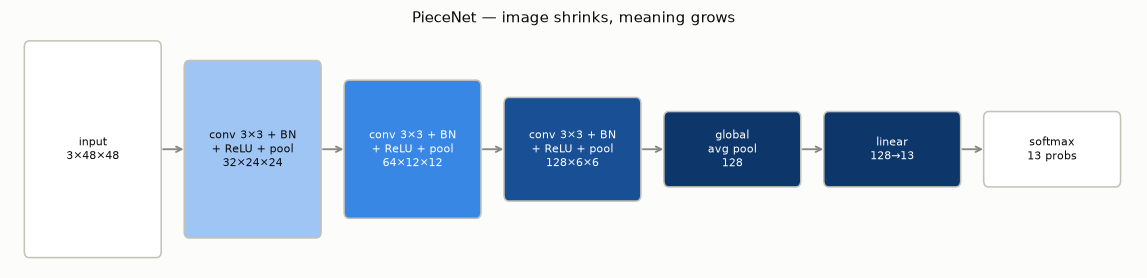

parameters: 95,373
ONNX file: 373 KB


In [9]:
# Architecture diagram (drawn to scale-ish: spatial size shrinks, channels grow)
fig, ax = plt.subplots(figsize=(10.5, 2.6))
ax.set_axis_off(); ax.grid(False)
layers = [("input\n3×48×48", 1.30, "white"), ("conv 3×3 + BN\n+ ReLU + pool\n32×24×24", 1.05, BLUES[1]),
          ("conv 3×3 + BN\n+ ReLU + pool\n64×12×12", 0.80, BLUES[3]),
          ("conv 3×3 + BN\n+ ReLU + pool\n128×6×6", 0.58, BLUES[5]),
          ("global\navg pool\n128", 0.40, BLUES[6]), ("linear\n128→13", 0.40, BLUES[6]),
          ("softmax\n13 probs", 0.40, "white")]
x = 0.0
for label, h, color in layers:
    ax.add_patch(mpl.patches.FancyBboxPatch((x, 0.7 - h / 2), 1.05, h,
                 boxstyle="round,pad=0.04", fc=color, ec=BASELINE, lw=1.0))
    dark = color in (BLUES[3], BLUES[5], BLUES[6])
    ax.text(x + 0.525, 0.7, label, ha="center", va="center", fontsize=7.5,
            color="white" if dark else INK, zorder=3)
    if x > 0:
        ax.annotate("", xy=(x - 0.02, 0.7), xytext=(x - 0.24, 0.7),
                    arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
    x += 1.32
ax.set_xlim(-0.15, x - 0.1); ax.set_ylim(-0.05, 1.45)
ax.set_title("PieceNet — image shrinks, meaning grows", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

import importlib.util
if importlib.util.find_spec("torch"):
    from training.train import PieceNet
    print(f"parameters: {sum(p.numel() for p in PieceNet().parameters()):,}")
print(f"ONNX file: {MODEL_PATH.stat().st_size / 1024:.0f} KB")

## 5. Training

Nothing exotic — the interesting engineering was all in the data. Cross-entropy
loss, Adam at 1e-3 with step decay (×0.3 at 60 % and 85 % of the run), batch 256,
and we keep whichever epoch scored best on validation:

```python
for epoch in range(epochs):
    for x, y in train_loader:
        loss = cross_entropy(model(x), y)
        loss.backward(); optimizer.step(); optimizer.zero_grad()
    scheduler.step()
    acc = accuracy(model, val_loader)         # held-out piece styles!
    if acc >= best_acc:
        best_acc = acc
        export_onnx(model, "piece_classifier.onnx")   # crash-safe: export every best
```

Try it yourself below — a couple of epochs on the demo dataset takes a minute or
two and already lands a surprisingly good score. The shipped model is the same
code run for 30 epochs on the full dataset; its real training curve follows.

In [10]:
# Hands-on: train a fresh PieceNet for 2 epochs on the demo dataset
if importlib.util.find_spec("torch"):
    from training.train import train_model
    demo_model, demo_acc = train_model(DATASET, epochs=2, batch_size=128)
    print(f"2-epoch demo model: {demo_acc:.2%} on never-seen piece styles")
else:
    print("PyTorch not installed — skipping the demo (pip install torch)")

epoch 1/2: val acc 73.5577%


epoch 2/2: val acc 94.9423%


2-epoch demo model: 94.94% on never-seen piece styles


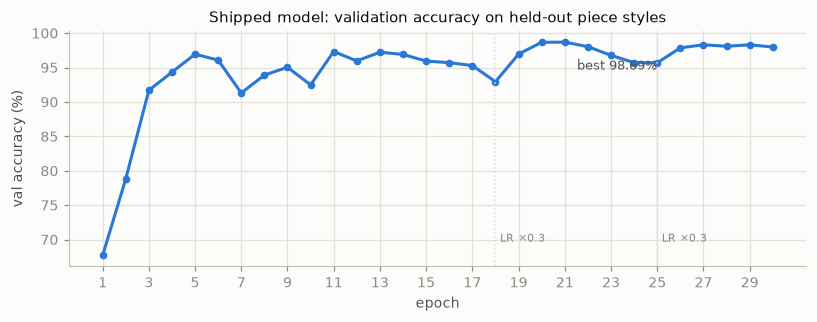

In [11]:
# The real 30-epoch run that produced the shipped model (docs/training_log.txt)
accs = [float(l.split("val acc")[1].rstrip("%")) / 100
        for l in (REPO / "docs/training_log.txt").read_text().splitlines()
        if l.startswith("epoch")]
epochs = np.arange(1, len(accs) + 1)
fig, ax = plt.subplots(figsize=(7.5, 3))
ax.plot(epochs, np.array(accs) * 100, color=BLUE, lw=2, marker="o", ms=4)
best = int(np.argmax(accs))
ax.annotate(f"best {accs[best]:.2%}", (epochs[best], accs[best] * 100),
            xytext=(8, -18), textcoords="offset points", fontsize=8.5, color=INK2)
for m, note in [(18, "LR ×0.3"), (25, "LR ×0.3")]:
    ax.axvline(m, color=GRID, lw=1, ls=":")
    ax.text(m + 0.2, min(accs) * 100 + 2, note, fontsize=7.5, color=MUTED)
ax.set_xlabel("epoch"); ax.set_ylabel("val accuracy (%)"); ax.set_xticks(epochs[::2])
ax.set_title("Shipped model: validation accuracy on held-out piece styles",
             fontsize=10, color=INK)
plt.tight_layout(); plt.show()

## 6. Validation & evaluation: the three gates

A single accuracy number hides too much, so evaluation happens at two levels and a
model must pass **three gates** before it ships (`python -m training.evaluate`):

- **Square level** — per-class accuracy on the held-out validation crops (which
  class gets confused with which?).
- **Board level** — whole positions rendered *the way a screen actually shows
  them*: legal-move dots, a mouse cursor, and the board crop misaligned by a few
  pixels. This runs twice: once on held-out styles (generalisation) and once on
  the site-default styles almost every player uses (deployment reality).

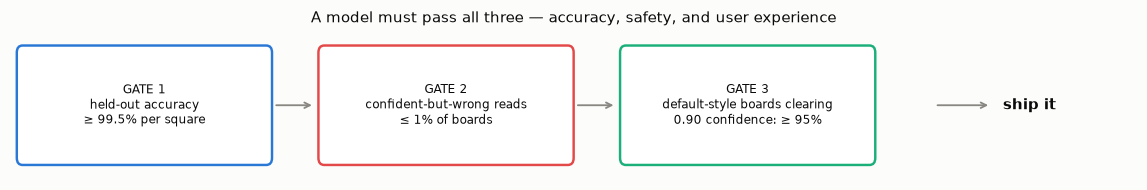

In [12]:
# Gate diagram
fig, ax = plt.subplots(figsize=(10.5, 1.8))
ax.set_axis_off(); ax.grid(False)
gates = [("GATE 1\nheld-out accuracy\n≥ 99.5% per square", BLUE),
         ("GATE 2\nconfident-but-wrong reads\n≤ 1% of boards", RED),
         ("GATE 3\ndefault-style boards clearing\n0.90 confidence: ≥ 95%", AQUA)]
for i, (label, color) in enumerate(gates):
    x = i * 2.6
    ax.add_patch(mpl.patches.FancyBboxPatch((x, 0.15), 2.1, 0.75, boxstyle="round,pad=0.05",
                 fc="white", ec=color, lw=1.6))
    ax.text(x + 1.05, 0.525, label, ha="center", va="center", fontsize=8, color=INK)
    if i < 2:
        ax.annotate("", xy=(x + 2.52, 0.525), xytext=(x + 2.16, 0.525),
                    arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
ax.annotate("", xy=(8.35, 0.525), xytext=(7.86, 0.525),
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
ax.text(8.45, 0.525, "ship it", fontsize=10, color=INK, va="center", weight="bold")
ax.set_xlim(-0.1, 9.6); ax.set_ylim(0, 1.05)
ax.set_title("A model must pass all three — accuracy, safety, and user experience",
             fontsize=10, color=INK)
plt.tight_layout(); plt.show()

held-out square accuracy: 98.6923%


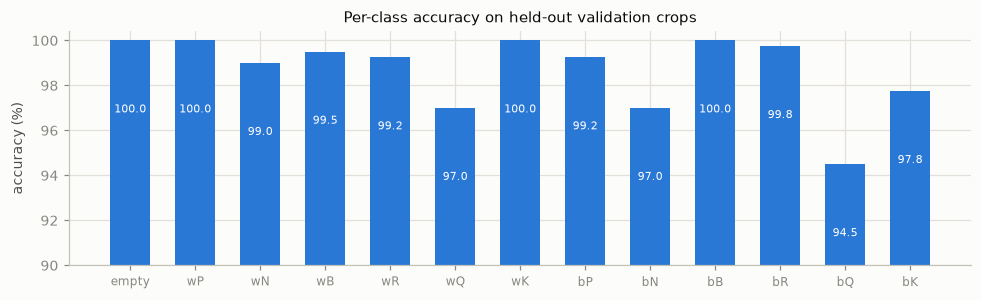

In [13]:
# Square level: per-class accuracy + where the mistakes go
from training.evaluate import eval_squares

squares = eval_squares(MODEL_PATH, DATASET)
accs_by_class = [squares["per_class"][c] for c in CLASSES]
print(f"held-out square accuracy: {squares['overall']:.4%}")

fig, ax = plt.subplots(figsize=(9, 2.8))
bars = ax.bar(np.arange(13), np.array(accs_by_class) * 100, color=BLUE, width=0.62)
for b, a in zip(bars, accs_by_class):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() - 3.2, f"{a * 100:.1f}",
            ha="center", fontsize=7.5, color="white")
ax.set_xticks(np.arange(13), CLASSES, fontsize=8)
ax.set_ylim(90, 100.4); ax.set_ylabel("accuracy (%)")
ax.set_title("Per-class accuracy on held-out validation crops", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

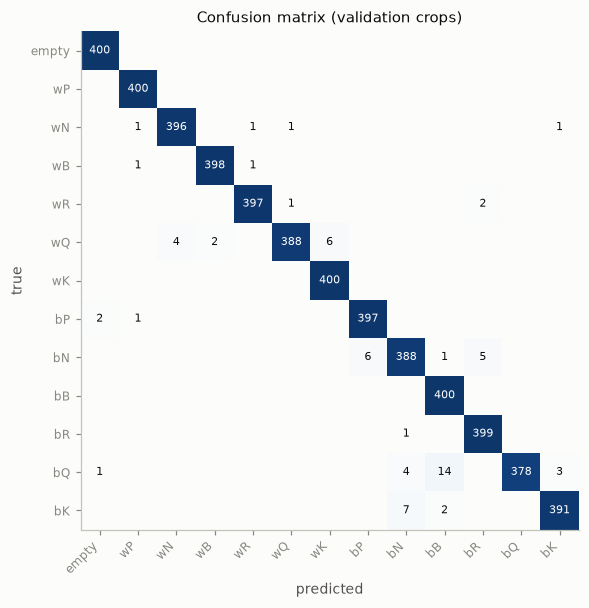

In [14]:
# Confusion matrix: the classic "which class does it mistake for which?"
net = recognizer._net
confusion = np.zeros((13, 13), int)
for idx, cls in enumerate(CLASSES):
    paths = sorted((DATASET / "val" / cls).glob("*.png"))
    imgs = np.stack([cv2.imread(str(p)) for p in paths])
    blob = cv2.dnn.blobFromImages(imgs, 1 / 255.0, (INPUT_SIZE, INPUT_SIZE), swapRB=False)
    net.setInput(blob)
    for p in net.forward().argmax(axis=1):
        confusion[idx, p] += 1

cmap = mpl.colors.LinearSegmentedColormap.from_list("brand_blues", [SURFACE] + BLUES)
row_norm = confusion / confusion.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6.4, 5.6))
ax.grid(False)
ax.imshow(row_norm, cmap=cmap, vmin=0, vmax=1)
ax.set_xticks(range(13), CLASSES, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(13), CLASSES, fontsize=8)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
for i in range(13):
    for j in range(13):
        if confusion[i, j]:
            ax.text(j, i, confusion[i, j], ha="center", va="center", fontsize=7,
                    color="white" if row_norm[i, j] > 0.5 else INK)
ax.set_title("Confusion matrix (validation crops)", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

In [15]:
# Board level: the three gates, live
from training.evaluate import DEPLOYED_SETS, eval_boards

boards = eval_boards(MODEL_PATH, ASSETS, n_positions=24, seed=0)
deployed = eval_boards(MODEL_PATH, ASSETS, n_positions=24, seed=0, set_names=DEPLOYED_SETS)
print("held-out styles (artifacts + misalignment):")
print(f"  per-square accuracy:      {boards['per_square']:.4%}   [gate 1: >= 99.5%]")
print(f"  confident-but-wrong:      {boards['misleading']:.2%}     [gate 2: <= 1%]")
print(f"  clearing 0.90 floor:      {boards['floor_clear']:.2%}    (reported)")
print("site-default styles:")
print(f"  per-square accuracy:      {deployed['per_square']:.4%}")
print(f"  clearing 0.90 floor:      {deployed['floor_clear']:.2%}    [gate 3: >= 95%]")

held-out styles (artifacts + misalignment):
  per-square accuracy:      99.8698%   [gate 1: >= 99.5%]
  confident-but-wrong:      0.00%     [gate 2: <= 1%]
  clearing 0.90 floor:      66.67%    (reported)
site-default styles:
  per-square accuracy:      100.0000%
  clearing 0.90 floor:      100.00%    [gate 3: >= 95%]


## 7. Reading a full board

End to end: image in → 8×8 grid of labels + a confidence per square out. The three
boards below use different styles, themes, sizes and orientations. The bot turns
the grid into a FEN string, hands it to Stockfish, and plays — which is why it can
join a game **from any position**, not just move one.

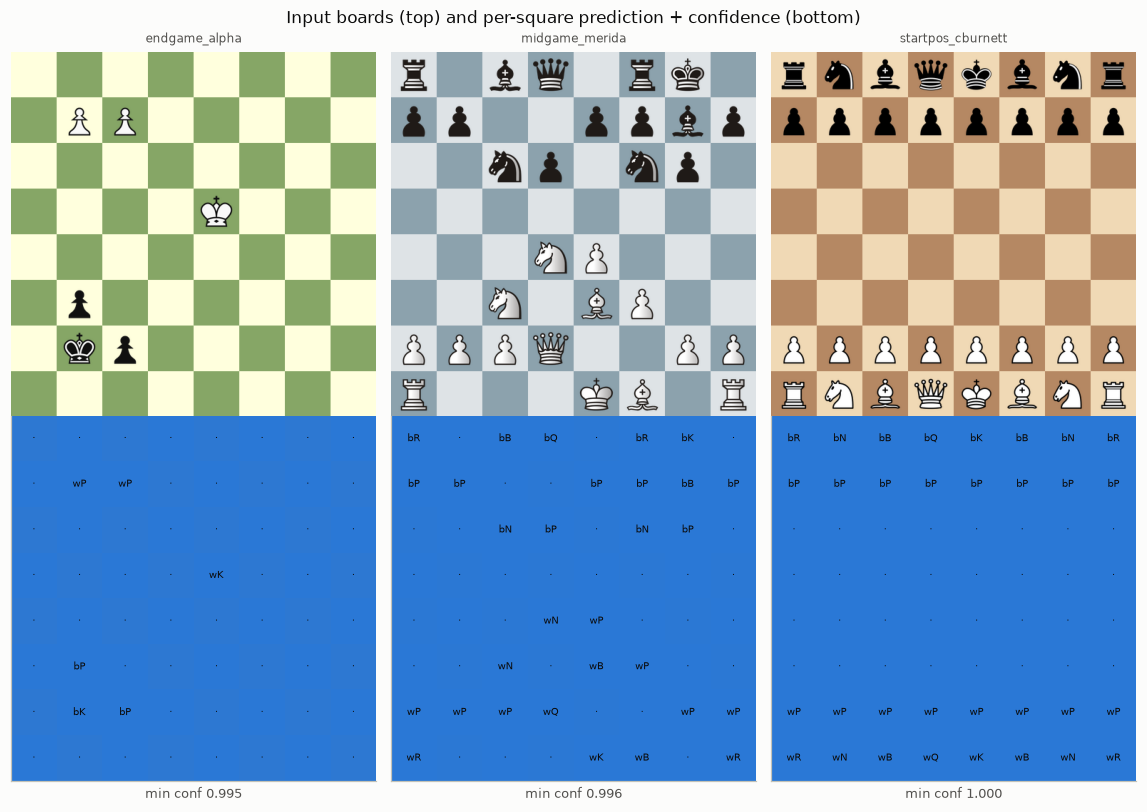

In [16]:
fixtures = sorted((REPO / "tests/fixtures").glob("board_*.png"))
fig, axes = plt.subplots(2, len(fixtures), figsize=(10.5, 7.4))
cmap = mpl.colors.LinearSegmentedColormap.from_list("conf", [RED, YELLOW, BLUE])
for col, path in enumerate(fixtures):
    img = cv2.imread(str(path))
    grid, conf = recognizer.classify_squares(img)
    show_bgr(axes[0][col], img, path.stem.replace("board_", ""))
    ax = axes[1][col]
    ax.grid(False)
    ax.imshow(conf, cmap=cmap, vmin=0.5, vmax=1.0)
    for r in range(8):
        for c in range(8):
            label = grid[r][c]
            ax.text(c, r, "·" if label == "empty" else label, ha="center", va="center",
                    fontsize=6.5, color="white" if conf[r, c] < 0.97 else INK)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(f"min conf {conf.min():.3f}", fontsize=8.5, color=INK2)
fig.suptitle("Input boards (top) and per-square prediction + confidence (bottom)",
             fontsize=11, color=INK)
plt.tight_layout(); plt.show()

## 8. The confidence bug hunt

The first version of all this worked beautifully in tests — and then, in real
games, the bot would sometimes refuse to play: *"confidence not enough."* The game
loop only trusts a read when **all 64 squares** clear a 0.90 confidence floor, so
one doubtful square rejects the whole board.

Reproducing real-screen conditions one at a time against that original model found
four culprits, all things a live site draws that my clean renders didn't:

| Scenario | worst-square confidence | verdict |
|---|---|---|
| clean render | 0.99 | fine |
| **board crop misaligned 2 px** | **0.89** | rejected |
| **misaligned 4–6 px** | **0.47–0.74** | rejected + misreads |
| **small board (32 px squares)** | **0.68** | rejected |
| **legal-move dots on empty squares** | **0.66** | *phantom black pawns!* |
| **mouse cursor on an empty square** | **0.56** | rejected |

Every failure was a **domain gap** — an appearance missing from training. The fix
came in three acts:

**Act 1 — fix the data.** All four artifacts became augmentations (§2). The
evaluation gate now injects them too, so this can never regress silently.

**Act 2 — respect honest uncertainty.** The retrained model *passed accuracy but
still failed confidence*. Tempting "fixes": lower the floor, or sharpen the
softmax. A calibration check said no — squares scored 0.8–0.9 really were only
~81 % correct. The model wasn't shy; it was **underfit** for the now-harder data.
Widening the net (24/48/96 → 32/64/128 channels) and training 30 epochs with LR
decay fixed what threshold-fiddling could not.

**Act 3 — fix the policy.** Styles the model has never seen legitimately earn less
confidence — no retraining changes that. So the game loop stopped treating the
floor as life-or-death: re-sync now keeps its *best legal read* and, if nothing
clears 0.90, adopts a read above a 0.80 soft floor instead of crashing the game
(measured wrong-adoption rate at that floor: **0.0 %**). And error messages now
name the doubtful squares — `e4=0.71, f6=0.83` — so the next bug hunt starts
where this one ended.

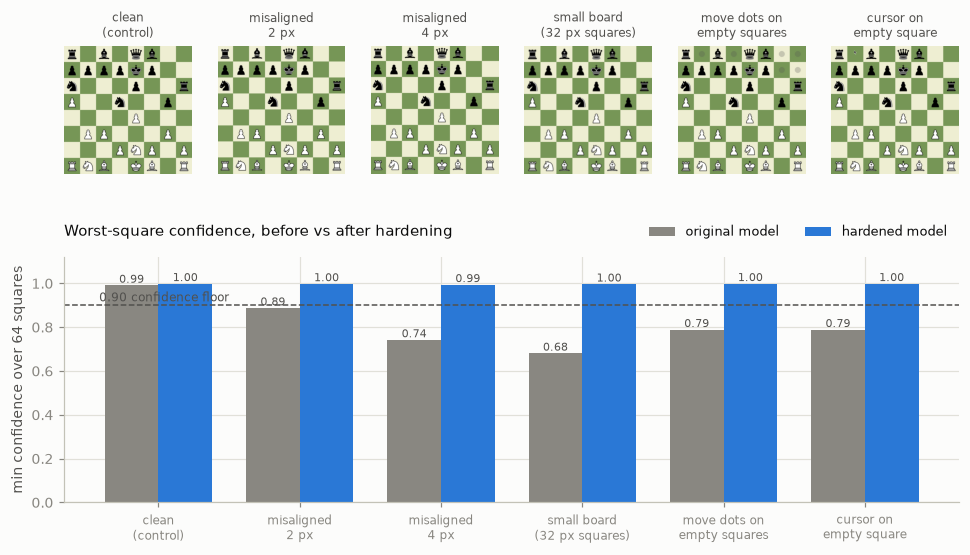

In [17]:
# Before vs after, on the exact scenarios that used to fail.
# (The "before" model is pulled from git history; skipped if unavailable.)
import tempfile
from training.generate_dataset import render_full_board

old_recognizer = None
try:
    blob = subprocess.run(["git", "cat-file", "blob", "53e8e0b:models/piece_classifier.onnx"],
                          capture_output=True, cwd=REPO).stdout
    if blob:
        old_path = Path(tempfile.gettempdir()) / "piece_classifier_original.onnx"
        old_path.write_bytes(blob)
        old_recognizer = Recognizer(model_path=old_path)
except Exception:
    pass

rng = random.Random(7)
board = chess.Board()
for _ in range(24):
    board.push(rng.choice(list(board.legal_moves)))
true_grid = board_to_grid(board, True)
base = render_full_board(cburnett, board, FLAT_THEMES[3], square_px=64)
SQ = 64

def with_shift(img, s):
    big = cv2.copyMakeBorder(img, 8, 8, 8, 8, cv2.BORDER_REFLECT)
    return big[8 + s:8 + s + 512, 8 + s:8 + s + 512]

def on_cell(img, row, col, fn):
    canvas = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).convert("RGBA")
    box = (col * SQ, row * SQ, (col + 1) * SQ, (row + 1) * SQ)
    cell = canvas.crop(box); fn(cell); canvas.paste(cell, box[:2])
    return cv2.cvtColor(np.asarray(canvas.convert("RGB")), cv2.COLOR_RGB2BGR)

empty_rc = next((r, c) for r in range(8) for c in range(8) if true_grid[r][c] == "empty")
dotted = base.copy()
for r, c in [(r, c) for r in range(8) for c in range(8) if true_grid[r][c] == "empty"][:6]:
    dotted = on_cell(dotted, r, c, lambda cell: _draw_move_marker(cell, random.Random(5), False))

scenarios = {
    "clean\n(control)": base,
    "misaligned\n2 px": with_shift(base, 2),
    "misaligned\n4 px": with_shift(base, 4),
    "small board\n(32 px squares)": cv2.resize(base, (256, 256), interpolation=cv2.INTER_AREA),
    "move dots on\nempty squares": dotted,
    "cursor on\nempty square": on_cell(base, *empty_rc,
                                        lambda cell: _draw_cursor(cell, random.Random(3))),
}
mins_new = [float(recognizer.classify_squares(img)[1].min()) for img in scenarios.values()]
mins_old = ([float(old_recognizer.classify_squares(img)[1].min()) for img in scenarios.values()]
            if old_recognizer else None)

fig = plt.figure(figsize=(10.5, 5.6))
gs = fig.add_gridspec(2, len(scenarios), height_ratios=[1, 1.5], hspace=0.32)
for i, (name, img) in enumerate(scenarios.items()):
    ax = fig.add_subplot(gs[0, i])
    show_bgr(ax, img if img.shape[0] == 512 else cv2.resize(img, (512, 512),
             interpolation=cv2.INTER_NEAREST), name)
ax = fig.add_subplot(gs[1, :])
x = np.arange(len(scenarios))
if mins_old:
    b1 = ax.bar(x - 0.19, mins_old, width=0.38, color=MUTED, label="original model")
    b2 = ax.bar(x + 0.19, mins_new, width=0.38, color=BLUE, label="hardened model")
    groups = (b1, b2)
else:
    groups = (ax.bar(x, mins_new, width=0.5, color=BLUE, label="hardened model"),)
for bars in groups:
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{b.get_height():.2f}", ha="center", fontsize=7.5, color=INK2)
ax.axhline(0.90, color=INK2, lw=1, ls="--")
ax.text(-0.42, 0.918, "0.90 confidence floor", fontsize=8, color=INK2, ha="left")
ax.set_xticks(x, list(scenarios), fontsize=8)
ax.set_ylim(0, 1.12); ax.set_ylabel("min confidence over 64 squares")
ax.legend(frameon=False, fontsize=8.5, loc="upper right", bbox_to_anchor=(1.0, 1.18), ncols=2)
ax.set_title("Worst-square confidence, before vs after hardening", fontsize=10, color=INK,
             loc="left", pad=14)
plt.show()

## 9. What ships, and what I'd tell a newcomer

**What ships:** a ~370 KB ONNX model that reads a full board in milliseconds on a
CPU. On the piece styles players actually use — with dots, cursors and misaligned
crops — **100 % of boards read perfectly and clear the strict confidence floor**.
The whole dataset was synthesized from ~4 MB of public art, with zero hand
labelling, and the game loop degrades gracefully instead of crashing when it meets
a board it is legitimately unsure about.

**Lessons that transfer to any ML project:**

1. **Look for label-free data first.** If you control the rendering, labels are a
   by-product, and "more data" becomes a parameter instead of a project.
2. **Split by source, not by sample** — otherwise validation measures memory, not
   generalisation.
3. **A confidence threshold is only as good as the training distribution.** My
   model wasn't underconfident — it was out of domain. Fix the data before
   touching the threshold.
4. **Check calibration before "fixing" confidence.** If low-confidence predictions
   really are wrong at that rate, sharpening the softmax is just lying to yourself.
5. **Evaluate what you deploy.** Clean-benchmark accuracy was 99.9 % while real
   screens failed. Put the dots, cursors and misalignment *in the gate*.
6. **Gate on what users experience; report what research wants.** Demanding top
   confidence on never-seen styles failed models that were perfect for every
   actual user.
7. **Crashing is a policy choice, not a model property.** The measured risk of the
   0.80-confidence fallback was zero; refusing it and dying mid-game was the real
   bug.
8. **Make errors name the failing part.** "Confidence not enough" cost a debugging
   session; "e4=0.71" would have cost a minute.